In [4]:
import pandas as pd
df = pd.read_csv("../data/raw/products.csv")

In [5]:
df

,name,price,currency,platform,url
0,HP Laptop,5000.0,MAD,Jumia,https://jumia.ma/hp
1,HP Laptop,5200.0,MAD,Avito,https://avito.ma/hp
2,HP Laptop,480.0,USD,Amazon,https://amazon.com/hp
3,HP Laptop,470.0,EUR,eBay,https://ebay.com/hp
4,HP Laptop,NaN,MAD,Jumia,https://jumia.ma/hp2
5,HP Laptop,5000.0,MAD,Jumia,https://jumia.ma/hp


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      6 non-null      object 
 1   price     5 non-null      float64
 2   currency  6 non-null      object 
 3   platform  6 non-null      object 
 4   url       6 non-null      object 
dtypes: float64(1), object(4)
memory usage: 372.0+ bytes


In [ ]:
df = df.dropna(subset=['price']) # pour extraire la colonne qui contient prices

In [ ]:
df['price'] = pd.to_numeric(df['price'], errors= 'coerce') #transformer price to number

C:\Users\moutc\AppData\Local\Temp\ipykernel_8788\2350328420.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price'] = pd.to_numeric(df['price'], errors= 'coerce')


In [10]:
df = df.dropna(subset = ['price']) 

In [11]:
df = df.drop_duplicates()

In [12]:
# ajuster currency
df['currency'] = df['currency'].fillna('MAD')

In [13]:
rates = {
    'MAD': 1,
    'USD': 10,
    'EUR': 11
}

df['price_mad'] = df.apply(lambda row: row['price'] * rates[row['currency']], axis=1)

In [14]:
df

,name,price,currency,platform,url,price_mad
0,HP Laptop,5000.0,MAD,Jumia,https://jumia.ma/hp,5000.0
1,HP Laptop,5200.0,MAD,Avito,https://avito.ma/hp,5200.0
2,HP Laptop,480.0,USD,Amazon,https://amazon.com/hp,4800.0
3,HP Laptop,470.0,EUR,eBay,https://ebay.com/hp,5170.0


In [15]:
df.head()

,name,price,currency,platform,url,price_mad
0,HP Laptop,5000.0,MAD,Jumia,https://jumia.ma/hp,5000.0
1,HP Laptop,5200.0,MAD,Avito,https://avito.ma/hp,5200.0
2,HP Laptop,480.0,USD,Amazon,https://amazon.com/hp,4800.0
3,HP Laptop,470.0,EUR,eBay,https://ebay.com/hp,5170.0


In [37]:
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [18]:
X = df[['price_mad']] #price_mad

In [23]:
# appliquer kmeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)

In [24]:
means = df.groupby('cluster')['price_mad'].mean().sort_values()

mapping = {
    means.index[0]: 'Low',
    means.index[1]: 'Medium',
    means.index[2]: 'High'
}

df['price_category'] = df['cluster'].map(mapping)

In [25]:
# afficher le cluster
df[['price_mad', 'cluster']]

,price_mad,cluster
0,5000.0,2
1,5200.0,0
2,4800.0,1
3,5170.0,0


In [ ]:
model = IsolationForest(contamination=0.2, random_state=42)

df['anomaly_label'] = df['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

In [33]:
df[['price_mad', 'anomaly_label']]

,price_mad,anomaly_label
0,5000.0,Normal
1,5200.0,Normal
2,4800.0,Anomaly
3,5170.0,Normal


In [34]:
stats = {
    "min_price": df['price_mad'].min(),
    "max_price": df['price_mad'].max(),
    "mean_price": df['price_mad'].mean(),
    "median_price": df['price_mad'].median(),
    "std_dev": df['price_mad'].std()
}

stats

{'min_price': np.float64(4800.0),
 'max_price': np.float64(5200.0),
 'mean_price': np.float64(5042.5),
 'median_price': np.float64(5085.0),
 'std_dev': np.float64(184.09689477736083)}

In [35]:
best_price = df['price_mad'].min()
best_price

np.float64(4800.0)

In [36]:
best_offers = df[df['price_mad'] == best_price]
best_offers

,name,price,currency,platform,url,price_mad,cluster,price_category,anomaly,anomaly_label
2,HP Laptop,480.0,USD,Amazon,https://amazon.com/hp,4800.0,1,Low,-1,Anomaly


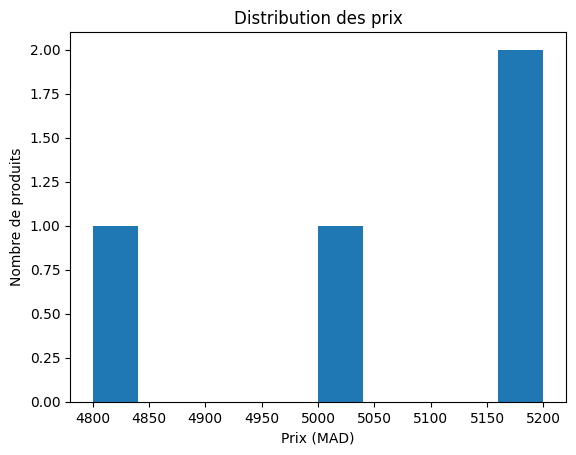

In [38]:
# histogram : visualiser la distribution des pris
plt.figure()
plt.hist(df['price_mad'], bins=10)
plt.title("Distribution des prix")
plt.xlabel("Prix (MAD)")
plt.ylabel("Nombre de produits")
plt.show()

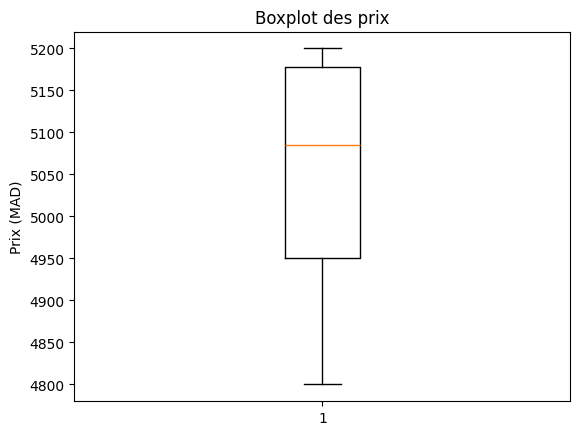

In [39]:
# Boxplot : la comparaison des prix 
plt.figure()
plt.boxplot(df['price_mad'])
plt.title("Boxplot des prix")
plt.ylabel("Prix (MAD)")
plt.show()

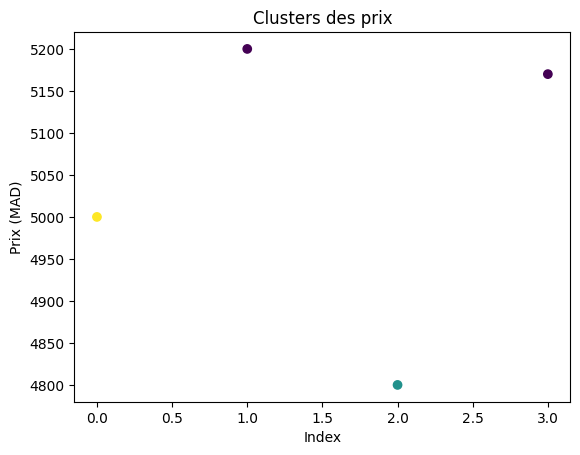

In [40]:
# Scatter : pour visualiser clusters : 
plt.figure()
plt.scatter(df.index, df['price_mad'], c=df['cluster'])
plt.title("Clusters des prix")
plt.xlabel("Index")
plt.ylabel("Prix (MAD)")
plt.show()